# COMP3314 Assignment 3: Image Classification Report

**Team Members:** Meng Xiangkun, Tu Jiawei, Xu Ruicong

## 1. Dataset Analysis

### 1.1 Data Overview

The dataset follows a CIFAR-10-style setup with **50,000 training images** and **10,000 test images** across **10 classes**: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck. Each image has resolution **32×32 RGB**.

From pipeline sanity checks in `MLClassifier.ipynb`:

- Sample tensor shape: `3×32×32`
- Data type: `float32`
- Pixel range after `ToTensor()`: approximately `[0, 1]`

### 1.2 Class Distribution

The training set is highly balanced. Class counts are:

| Class Label | Class Name  | Number of Samples | Percentage |
|-------------|-------------|-------------------|------------|
| 0 | airplane   | 5,027 | 10.05% |
| 1 | automobile | 5,008 | 10.02% |
| 2 | bird       | 5,026 | 10.05% |
| 3 | cat        | 4,946 | 9.89%  |
| 4 | deer       | 5,061 | 10.12% |
| 5 | dog        | 5,005 | 10.01% |
| 6 | frog       | 4,962 | 9.92%  |
| 7 | horse      | 5,006 | 10.01% |
| 8 | ship       | 5,012 | 10.02% |
| 9 | truck      | 4,947 | 9.89%  |
| **Total** | - | **50,000** | **100%** |

The largest class (deer) and smallest class (cat) differ by only **115 samples** (~2.3% of one class). Therefore, no resampling strategy was required, and accuracy is an appropriate primary metric.

### 1.3 Data Visualization

#### Figure 2: Bar Chart & Pie Chart
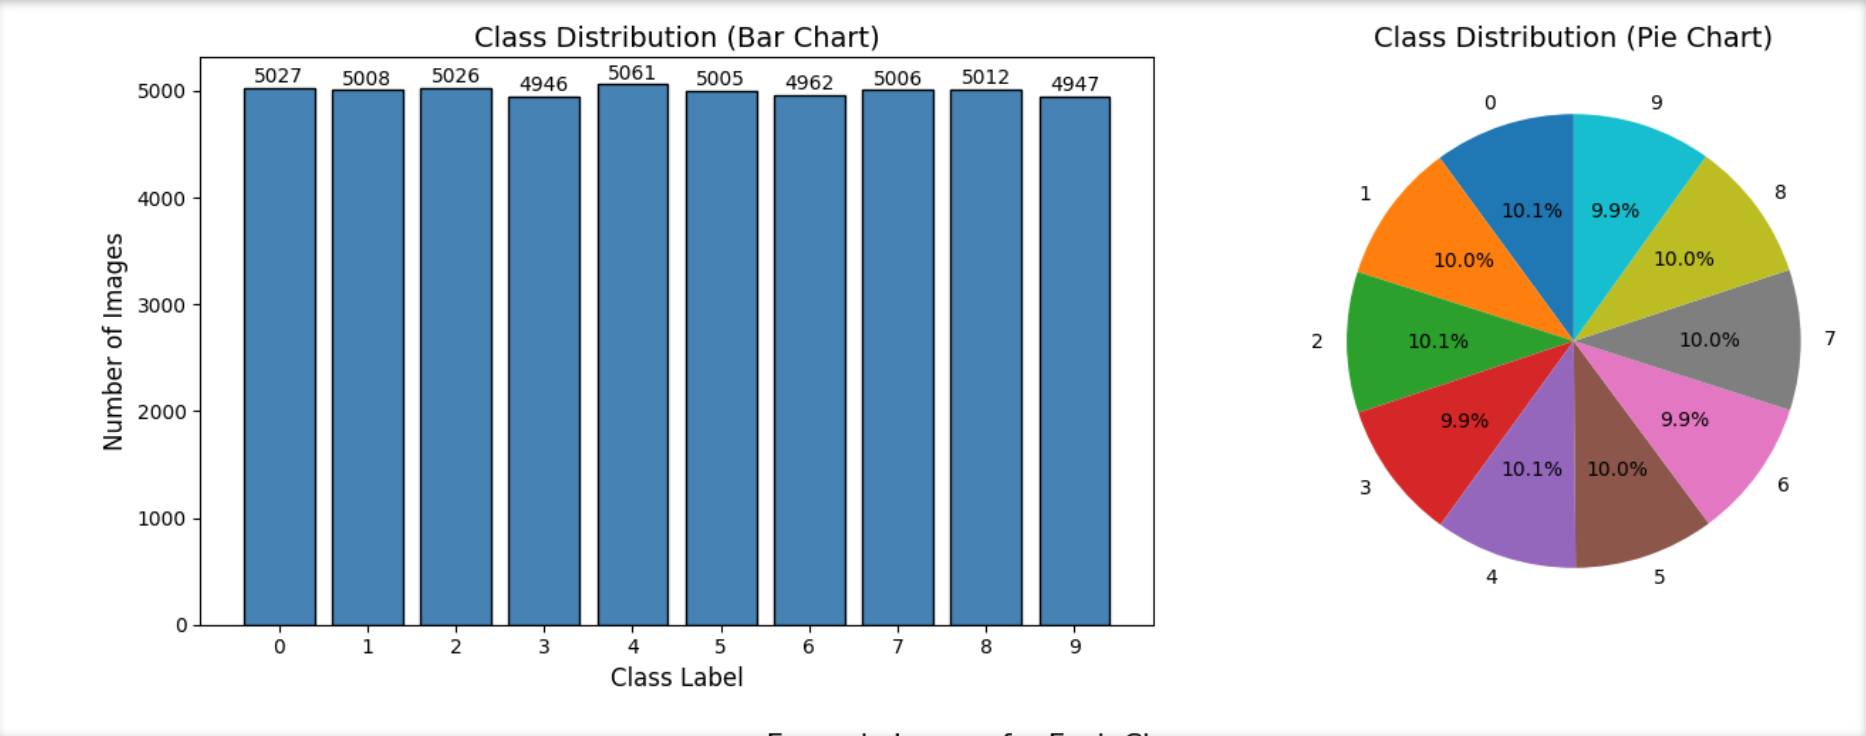

*Figure 2 shows near-uniform class frequencies, supporting the balanced-data assumption used in training and evaluation.*

#### Figure 3: One Example per Class
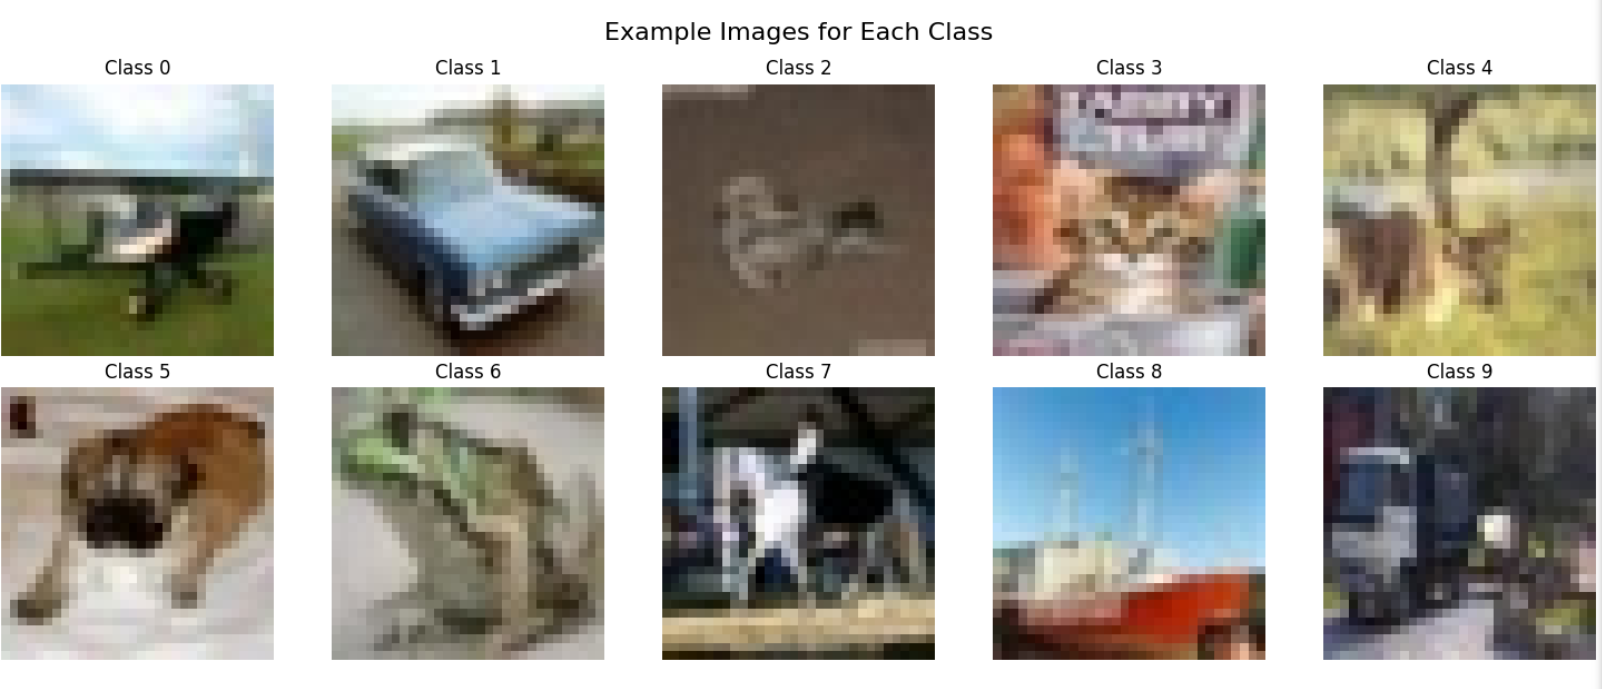

*Figure 3 provides representative visual samples for all 10 classes and confirms expected semantic categories.*

---

## 2. Methodology and Classifier Exploration

### 2.1 End-to-End Pipeline

Our final system in `MLClassifier.ipynb` is a **feature-engineering + classical ML** pipeline:

1. Load `train.csv` / `test.csv` with a custom PyTorch Dataset (`im_name`-based file mapping).
2. Extract fixed wavelet scattering features using `Scattering2D(J=2, shape=(32, 32))`.
3. Cache extracted batches to disk (`cache/train_batch_*.npy`, `cache/test_batch_*.npy`) for resumability and OOM safety.
4. Fit global `StandardScaler` on train features only, then transform train/test.
5. Run PCA + classifier search on a stratified subset (`SEARCH_ROWS=12000`, 3-fold CV).
6. Train final models on full training data; apply horizontal-flip TTA on test set.
7. Fuse base + TTA scores, select best model, and export `submission.csv` (`im_name,label`).

### 2.2 Why Wavelet Scattering + Classical ML

- **Scattering features** are stable to small translations/deformations and do not require backprop-based feature learning.
- **Classical classifiers** are computationally lighter than deep CNN training for this assignment setup.
- **Batch caching + cleanup** allows robust execution under memory constraints and supports interrupted-session recovery.
- **GPU-first / CPU-fallback design** keeps the notebook portable across environments.

### 2.3 Candidate Classifiers

We trained and compared two models on the PCA feature space:

- **RBF SVM** (`SVC`)
- **Logistic Regression** (`LogisticRegression`)

Search spaces used in the notebook:

- `n_components ∈ {768, 1024, 1536}`
- `C ∈ {5.0, 8.0, 10.0, 12.0}`
- `gamma ∈ {'scale'}` for SVM

Model ranking criterion:

$$
\text{Robust Score} = \text{CV Mean Accuracy} - 0.5 \times \text{CV Std}
$$

This criterion favors both high accuracy and cross-fold stability.

### 2.4 Search Results (from notebook output)

Best configurations found:

- **Best SVM:** `n_components=1024`, `C=5.0`, `gamma='scale'`, CV = `0.66058 ± 0.00892`, robust score = `0.65612`
- **Best LR:** `n_components=1536`, `C=5.0`, CV = `0.57675 ± 0.00255`, robust score = `0.57548`

Comparison summary:

| Classifier | Best CV Mean | Best CV Std | Robust Score |
|-----------|---------------|-------------|--------------|
| RBF SVM | 66.06% | 0.89% | 65.61% |
| Logistic Regression | 57.68% | 0.25% | 57.55% |

**Observation:** SVM consistently and substantially outperforms LR, indicating that class boundaries remain non-linear even after PCA.

---

## 3. Final Solution and Inference Strategy

### 3.1 Final Training Configuration

Based on search outcomes, the final branch uses:

- Scattering: `J=2`, input shape `(32, 32)`
- Batch size: `128`
- Scaler: `StandardScaler(with_mean=True, with_std=True)` fit on train set
- Final PCA dimension: `1024`
- Primary classifier: `RBF SVM(C=5.0, gamma='scale')`
- Backup classifier: logistic regression fallback if SVM training fails

### 3.2 Test-Time Augmentation (TTA)

We apply **horizontal flip TTA** at inference time:

1. Predict class scores on original test images.
2. Predict class scores on horizontally flipped test images.
3. Average the two score vectors with equal weight (0.5 / 0.5).
4. Output class by `argmax` of the fused scores.

Empirical consistency from notebook logs:

- SVM base vs TTA prediction agreement: **0.8146**
- LR base vs TTA prediction agreement: **0.7653**

This indicates TTA provides complementary information while preserving prediction stability.

### 3.3 Final Model Selection and Submission

Notebook output shows the final decision rule selected **SVM** because its CV score is higher than LR:

- Selected model: **SVM** (`0.66058 > 0.57675`)
- Prediction rows generated: **10,000**
- Submission format: `im_name,label`
- Output file: `./submission.csv`

---

## 4. Performance Summary and Discussion

### 4.1 Public Leaderboard Result

The final pipeline achieved **0.74950 accuracy on Kaggle**.

### 4.2 Strengths

- Strong non-deep-learning baseline with reproducible, restart-friendly engineering.
- Robust memory handling via feature caching and explicit cleanup.
- Clear CPU fallback path when RAPIDS/CUDA is unavailable.
- Simple but effective TTA score fusion.

### 4.3 Limitations and Future Work

- Scattering + PCA may still discard fine-grained class cues compared with modern deep models.
- Search budget is intentionally constrained for runtime; wider hyperparameter ranges may further improve score.
- Future extensions can include multi-view TTA, calibrated ensembling, or lightweight CNN fine-tuning as a hybrid head.

## 5. Conclusion

We implemented a complete and practical image-classification pipeline using wavelet scattering features and classical machine learning. Through systematic search, robust-score-based model selection, and TTA-enhanced inference, the final SVM-based system delivered competitive performance while maintaining strong reproducibility and runtime stability for assignment-scale experimentation.